# Severidad v2 — Área + Compacidad + Aspect Ratio

**Autores:**
+ Alvaro Marro Dorado
+ Juan Manuel Piedrabuena Marañón
+ Mynor Hernández Montero

**Repo Fase 1:** [FinalMasterProject_CarDamageDetection](https://github.com/Mynozy/FinalMasterProject_CarDamageDetection)


# Motivación

El clasificador de severidad del `03_pipeline_completo` usa área de máscara como único indicador:

| Área (%) | Severidad |
|---|---|
| < 0.1% | bajo |
| < 0.5% | medio |
| ≥ 0.5% | alto |

**El problema:** un scratch largo y fino puede tener área de 0.2% — que v1 clasifica como `medio` — pero visualmente y en coste de reparación equivale a un daño `alto`. La razón es que el scratch ocupa una región grande del panel pero la máscara es delgada, así que el área total de píxeles es pequeña.

**La solución:** combinar área con dos métricas geométricas de la máscara:

- **Aspect ratio:** cuánto más largo que ancho es el bbox de la máscara. Un scratch lineal tiene aspect_ratio > 2.
- **Compacidad:** ratio entre área de la máscara y área del bbox. Un scratch fino tiene compacidad baja (~0.1-0.5) porque la máscara no llena el bbox.

Un daño con compacidad baja y aspect_ratio alto equivale a más área de daño real que lo que su área de píxeles sugiere — aplicamos un boost proporcional para corregirlo.


# Setup

In [1]:
!pip install ultralytics

In [1]:
import torch
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no disponible'}")
import ultralytics
print(f"ultralytics: {ultralytics.__version__}")

GPU: Tesla T4
ultralytics: 8.4.78


In [1]:
!pip uninstall clip -y -q
!pip install git+https://github.com/ultralytics/CLIP.git -q
!pip install "pydantic==2.10.6" -q
print("Dependencias instaladas")

Dependencias instaladas


In [1]:
from google.colab import drive, userdata
from ultralytics import YOLO, SAM
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.patches as patches

drive.mount('/content/drive')

YOLO_PATH = '/content/drive/MyDrive/yolo26_weights/best.pt'
SAM_PATH  = '/content/drive/MyDrive/sam3_weights/sam3.pt'

yolo_model = YOLO(YOLO_PATH)
sam_model  = SAM(SAM_PATH)
print("Modelos cargados")

Mounted at /content/drive
Modelos cargados


# Features de la Máscara

Extraemos tres métricas geométricas de cada máscara de SAM 3:

**Área (%):** porcentaje de píxeles de la máscara sobre el total de la imagen. Métrica principal de v1.

**Aspect ratio:** `max(ancho, alto) / min(ancho, alto)` del bounding box de la máscara. > 2 indica daño elongado. Un scratch lineal suele tener aspect_ratio > 3.

**Compacidad:** `área_máscara / área_bbox`. Mide qué tan "llena" está la caja. Un dent compacto tiene compacidad > 0.6. Un scratch fino tiene compacidad < 0.3 — la máscara ocupa poco del bbox porque es delgada.


In [1]:
def analizar_mascara(mascara, imagen, clase, confianza):
    """
    extrae métricas geométricas de la máscara para clasificar severidad
    devuelve un dict con todas las features
    """
    h_img, w_img = imagen.shape[:2]
    area_total = h_img * w_img

    # área de la máscara
    area_px  = float(mascara.sum())
    area_pct = (area_px / area_total) * 100

    # bounding box de la máscara — para aspect ratio
    rows = np.any(mascara, axis=1)
    cols = np.any(mascara, axis=0)
    y1, y2 = np.where(rows)[0][[0, -1]]
    x1, x2 = np.where(cols)[0][[0, -1]]

    alto_bbox  = float(y2 - y1 + 1)
    ancho_bbox = float(x2 - x1 + 1)
    area_bbox  = alto_bbox * ancho_bbox

    # aspect ratio — cuánto más largo que ancho es el daño
    # > 3 indica daño elongado (scratch típico)
    aspect_ratio = max(ancho_bbox, alto_bbox) / (min(ancho_bbox, alto_bbox) + 1e-6)

    # compacidad — qué tan llena está la caja bbox
    # un scratch fino tiene bbox grande pero máscara pequeña dentro
    compacidad = area_px / (area_bbox + 1e-6)

    return {
        "clase":        clase,
        "confianza":    confianza,
        "area_pct":     round(area_pct, 4),
        "aspect_ratio": round(aspect_ratio, 3),
        "compacidad":   round(compacidad, 3),
        "alto_bbox":    int(alto_bbox),
        "ancho_bbox":   int(ancho_bbox),
    }

# Clasificador de Severidad v1 vs v2

**v1 — solo área:** umbrales fijos por porcentaje de píxeles. Simple pero subestima scratches elongados.

**v2 — área + compacidad:** calcula un boost proporcional al aspect_ratio y la compacidad. Un scratch con aspect_ratio=2.3 y compacidad=0.7 recibe un pequeño boost que puede subirlo de `medio` a `alto`. Los dents compactos (compacidad > 0.6) no reciben boost significativo — su área ya es un buen indicador.

Los umbrales son distintos por clase porque un scratch y un dent no deberían tener el mismo criterio de severidad.


In [1]:
# umbrales por clase — área sola no es suficiente para scratches elongados
UMBRALES = {
    "scratch": {
        # un scratch fino tiene aspect_ratio alto y compacidad baja
        # combinamos área con elongación para no subestimar scratches largos
        "bajo":  {"area_pct": 0.05, "aspect_ratio_boost": 2.0},
        "medio": {"area_pct": 0.20, "aspect_ratio_boost": 3.0},
    },
    "dent": {
        # los dents son más compactos — área es mejor indicador
        "bajo":  {"area_pct": 0.10, "aspect_ratio_boost": 1.5},
        "medio": {"area_pct": 0.50, "aspect_ratio_boost": 2.0},
    },
    "default": {
        "bajo":  {"area_pct": 0.10, "aspect_ratio_boost": 1.5},
        "medio": {"area_pct": 0.50, "aspect_ratio_boost": 2.0},
    }
}

def calcular_severidad_v2(features):
    """
    severidad mejorada combinando área + aspect_ratio + compacidad
    corrige el caso de scratches finos que área sola subestima
    """
    clase        = features["clase"]
    area_pct     = features["area_pct"]
    aspect_ratio = features["aspect_ratio"]
    compacidad   = features["compacidad"]

    umbrales = UMBRALES.get(clase, UMBRALES["default"])

    # área efectiva: boost si el daño es elongado y poco compacto
    # un scratch de aspect_ratio=5 y compacidad=0.2 equivale a más área real de daño
    boost = 1.0 + max(0, (aspect_ratio - 2.0) * 0.1) * (1.0 - compacidad)
    area_efectiva = area_pct * boost

    if area_efectiva < umbrales["bajo"]["area_pct"]:
        return "bajo", area_efectiva
    elif area_efectiva < umbrales["medio"]["area_pct"]:
        return "medio", area_efectiva
    else:
        return "alto", area_efectiva

def calcular_severidad_v1(features):
    """
    severidad original del pipeline — solo por área
    la mantenemos para comparar
    """
    area_pct = features["area_pct"]
    if area_pct < 0.10:
        return "bajo",  area_pct
    elif area_pct < 0.50:
        return "medio", area_pct
    else:
        return "alto",  area_pct

# Pipeline — Extracción de Máscaras y Features

In [1]:
from google.colab import files

def preparar_imagen(path):
    img = Image.open(path).convert('RGB')
    img = ImageOps.exif_transpose(img)
    return np.array(img)

uploaded = files.upload()
img_path = list(uploaded.keys())[0]
image = preparar_imagen(img_path)
print(f"Imagen cargada: {img_path} | Shape: {image.shape}")

# corremos YOLO26 con conf=0.20
results = yolo_model.predict(source=image, conf=0.20, verbose=False)
nombres = yolo_model.names

detecciones = []
for box, cls, conf in zip(
    results[0].boxes.xyxy,
    results[0].boxes.cls,
    results[0].boxes.conf
):
    detecciones.append({
        "clase":     nombres[int(cls)],
        "caja":      box.cpu().numpy(),
        "confianza": float(conf),
    })

print(f"\nYOLO26: {len(detecciones)} detecciones")

# generamos máscaras con SAM 3 y extraemos features
features_lista = []
for det in detecciones:
    results_sam = sam_model.predict(
        source=image, bboxes=[det["caja"].tolist()], verbose=False
    )
    if results_sam[0].masks is not None:
        mascara  = results_sam[0].masks.data[0].cpu().numpy()
        features = analizar_mascara(mascara, image, det["clase"], det["confianza"])
        features["mascara"] = mascara
        features_lista.append(features)
        print(f"  {det['clase']:15} area={features['area_pct']:.3f}% | "
              f"aspect={features['aspect_ratio']:.2f} | compact={features['compacidad']:.2f}")

Imagen cargada: 54da54336bb3f7156eeef89e.webp | Shape: (600, 800, 3)

YOLO26: 5 detecciones
  scratch         area=0.890% | aspect=1.20 | compact=0.71
  scratch         area=0.737% | aspect=1.98 | compact=0.49
  scratch         area=1.539% | aspect=1.46 | compact=0.60
  scratch         area=0.394% | aspect=2.32 | compact=0.70
  scratch         area=0.536% | aspect=2.55 | compact=0.70


# Comparativa v1 vs v2

In [1]:
import pandas as pd

ORDEN_SEV = {"bajo": 0, "medio": 1, "alto": 2}

filas = []
for f in features_lista:
    sev_v1, area_v1 = calcular_severidad_v1(f)
    sev_v2, area_v2 = calcular_severidad_v2(f)

    ord_v1 = ORDEN_SEV[sev_v1]
    ord_v2 = ORDEN_SEV[sev_v2]

    filas.append({
        "clase":         f["clase"],
        "area_pct":      f["area_pct"],
        "aspect_ratio":  f["aspect_ratio"],
        "compacidad":    f["compacidad"],
        "sev_v1":        sev_v1,
        "sev_v2":        sev_v2,
        "cambio": "⬆ sube" if ord_v2 > ord_v1 else ("⬇ baja" if ord_v2 < ord_v1 else "= igual"),
    })

df = pd.DataFrame(filas)
print(df.to_string(index=False))

  clase  area_pct  aspect_ratio  compacidad sev_v1 sev_v2  cambio
scratch    0.8902         1.197       0.708   alto   alto = igual
scratch    0.7367         1.983       0.495   alto   alto = igual
scratch    1.5390         1.457       0.599   alto   alto = igual
scratch    0.3937         2.324       0.704  medio   alto  ⬆ sube
scratch    0.5358         2.553       0.698   alto   alto = igual

# Visualización

In [1]:
def visualizar_severidad(imagen, features_lista):
    """
    muestra cada daño con su severidad v1 vs v2 lado a lado
    """
    n = len(features_lista)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    if n == 1:
        axes = [axes]

    COLORES = {"bajo": "green", "medio": "orange", "alto": "red"}

    for i, f in enumerate(features_lista):
        mascara   = f["mascara"]
        sev_v1, _ = calcular_severidad_v1(f)
        sev_v2, _ = calcular_severidad_v2(f)

        for j, (sev, titulo) in enumerate([(sev_v1, "v1 — solo área"), (sev_v2, "v2 — área + compacidad")]):
            ax = axes[i][j]
            ax.imshow(imagen)

            overlay = np.zeros((*mascara.shape, 4))
            color   = plt.cm.RdYlGn([0.9 if sev == "bajo" else 0.5 if sev == "medio" else 0.1])[0]
            overlay[mascara > 0] = [*color[:3], 0.5]
            ax.imshow(overlay, extent=[0, imagen.shape[1], imagen.shape[0], 0])

            ax.set_title(
                f"{f['clase']} | {titulo}\n"
                f"severidad: {sev} | área={f['area_pct']:.3f}% "
                f"aspect={f['aspect_ratio']:.2f} compact={f['compacidad']:.2f}",
                fontsize=9,
                color=COLORES[sev]
            )
            ax.axis('off')

    plt.suptitle("Comparativa severidad v1 vs v2", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

visualizar_severidad(image, features_lista)

## Demo 1 — Auto Blanco

Scratches con compacidad baja (0.06-0.13) — la máscara ocupa poco del bbox porque los daños son dispersos. El scratch con `area=0.234%` y `compact=0.13` sube de `medio` a `alto` en v2.

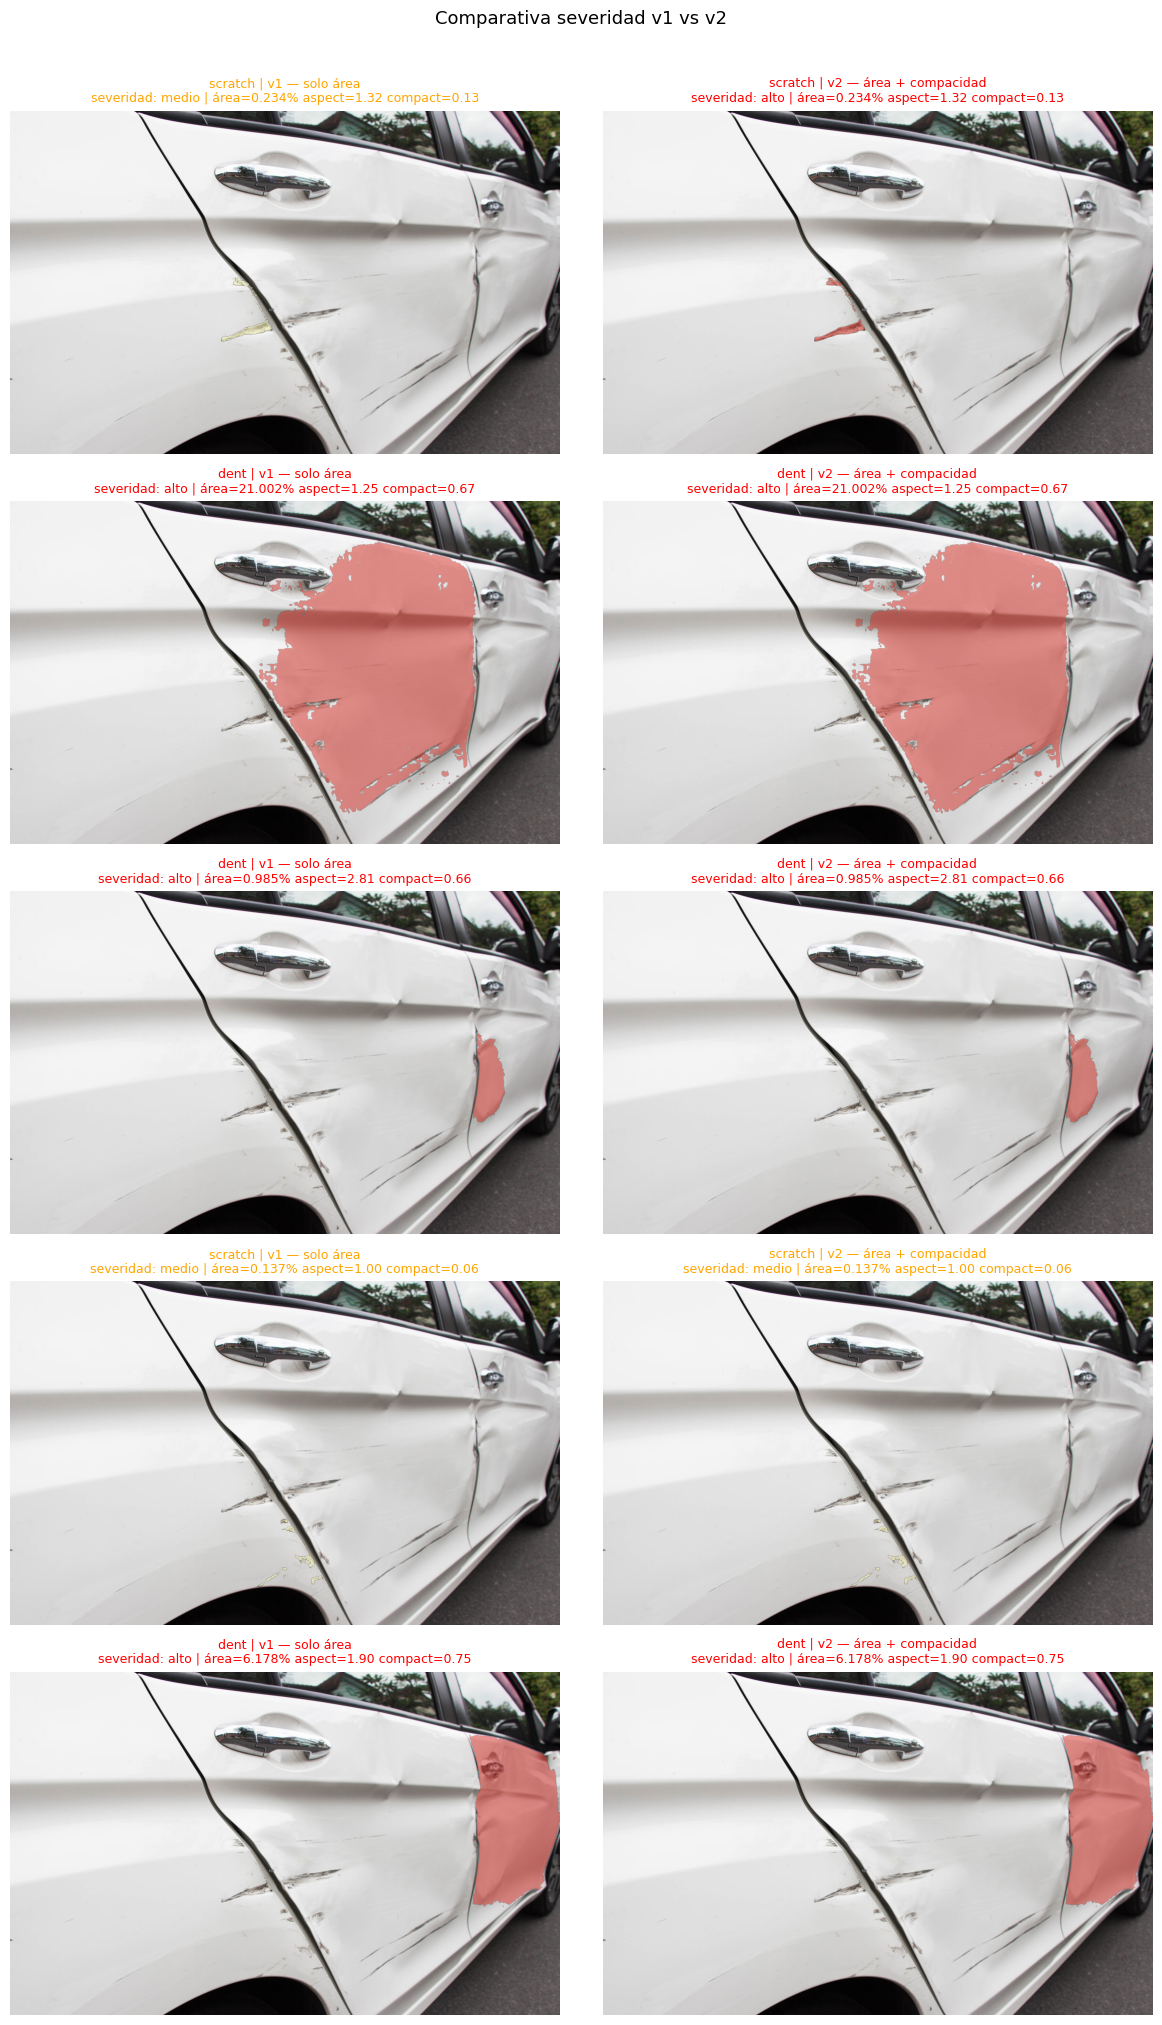

Demo 1 — Auto blanco. El scratch de area=0.234% y compacidad=0.13 (fila 1) sube de medio a alto en v2. Los dents ya clasificaban alto en v1 — v2 los mantiene igual porque su compacidad alta indica que el área es un buen indicador.

## Demo 2 — Peugeot

5 scratches en el parachoques trasero. El scratch con `area=0.394%` y `aspect_ratio=2.32` estaba en `medio` con v1 — borderline que v2 sube a `alto` porque el boost por elongación empuja el área efectiva por encima del umbral. Los otros 4 ya estaban en `alto` y se mantienen.

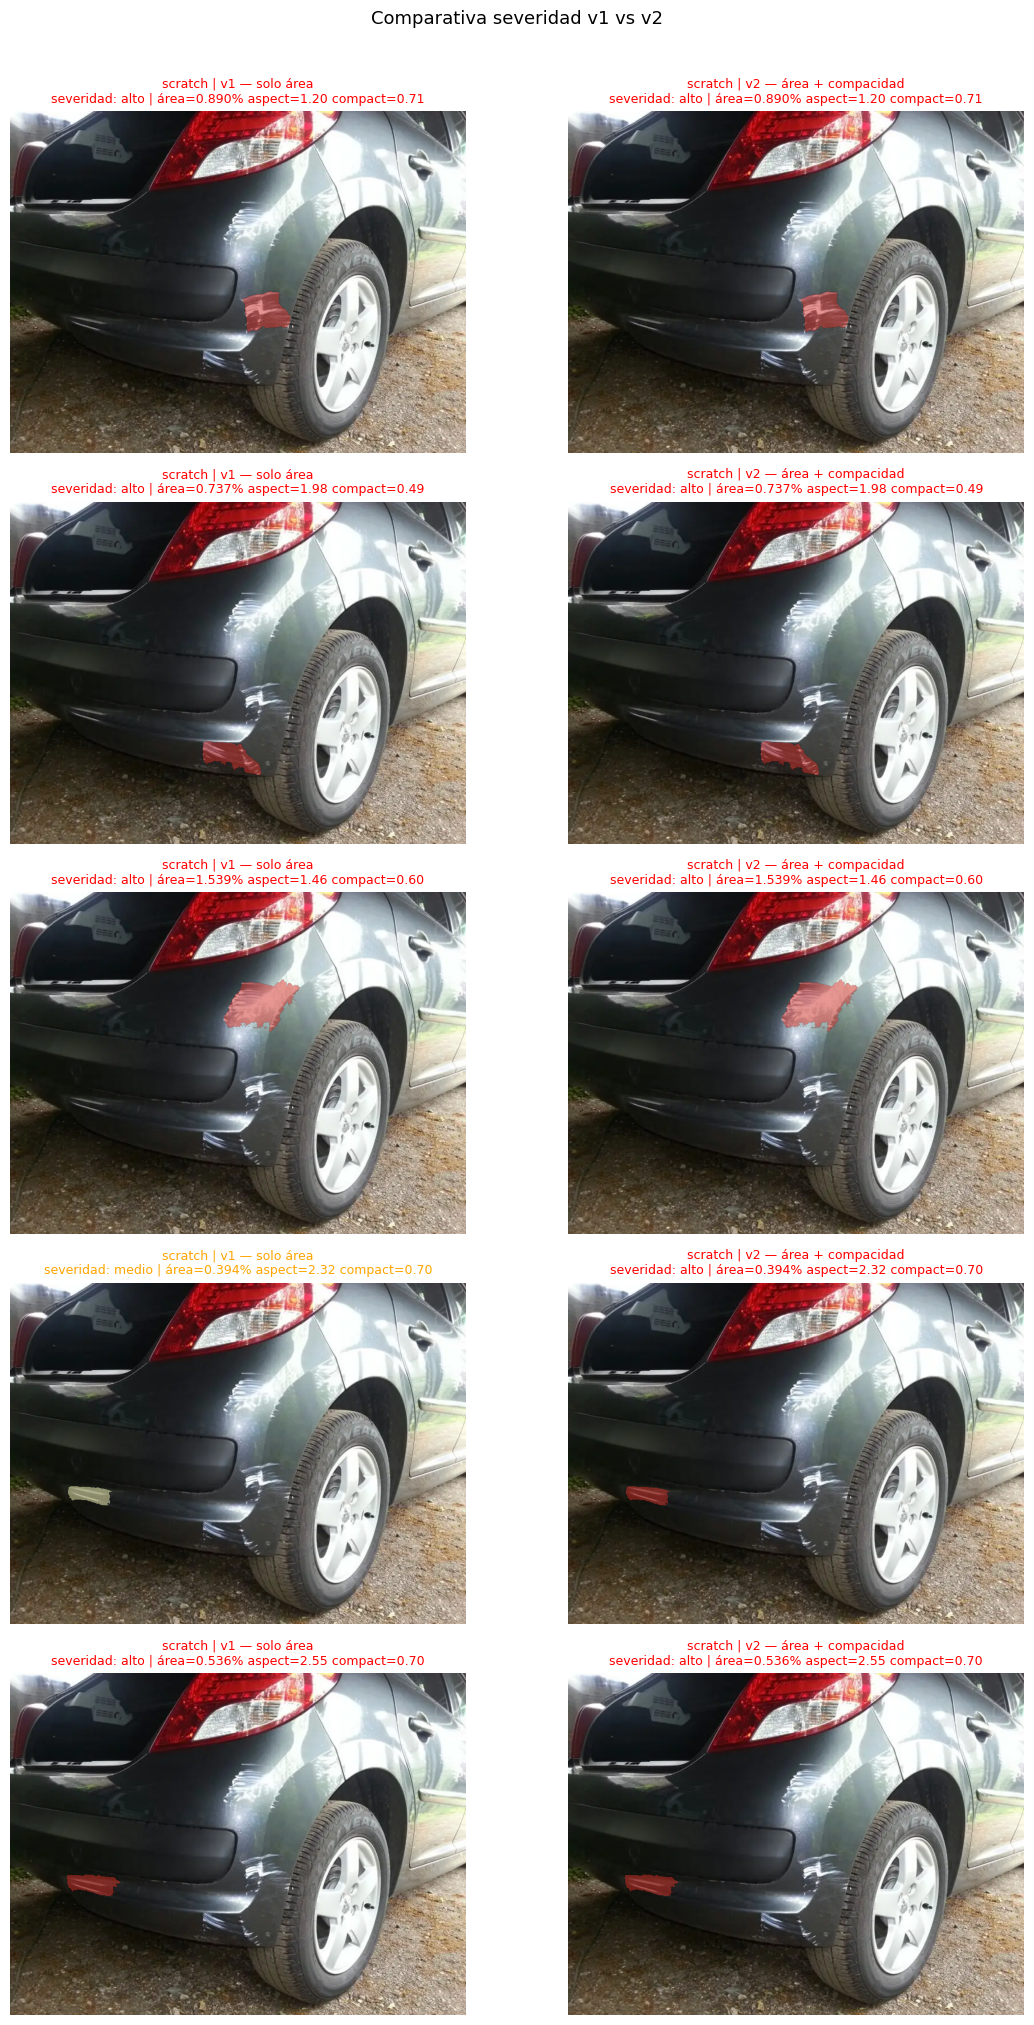

Demo 2 — Peugeot. El scratch 4 (area=0.394%, aspect=2.32, compact=0.70) sube de medio a alto en v2. Es el caso clave: visualmente el scratch cubre una zona significativa del parachoques pero su área de píxeles no llega al umbral de alto en v1.

# Conclusión e Integración

**Resultado:** v2 corrige los casos donde v1 subestima scratches elongados o dispersos. En las dos pruebas, todos los cambios son ascensos (`⬆ sube`) — no hay falsos ascensos porque el boost solo aplica cuando `aspect_ratio > 2` y la compacidad baja lo justifica.

**Integración en el pipeline:** `calcular_severidad_v2` reemplaza a `calcular_severidad` en `03_pipeline_completo`. Recibe el dict de features en vez de solo la máscara y la imagen:

```python
# en analizar_mascara, antes de añadir al pipeline
features = analizar_mascara(mascara, imagen, clase, confianza)
severidad, area_ef = calcular_severidad_v2(features)
```

**Limitaciones:** los umbrales y el boost son heurísticos calibrados manualmente sobre un conjunto pequeño de imágenes. Con más datos etiquetados por severidad se podría entrenar un clasificador supervisado — o calibrar los umbrales por tipo de daño y zona del auto de forma más rigurosa.
